In [1]:
import pandas as pd


In [2]:
store_df = pd.read_csv('/content/store.csv')
train_df = pd.read_csv('/content/train.csv')

/tmp/ipykernel_6175/1965746258.py:2: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv('/content/train.csv')


In [3]:
display(store_df.head())

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [4]:
display(train_df.head())

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5.0,2015-07-31,5263.0,555.0,1.0,1.0,0,1.0
1,2,5.0,2015-07-31,6064.0,625.0,1.0,1.0,0,1.0
2,3,5.0,2015-07-31,8314.0,821.0,1.0,1.0,0,1.0
3,4,5.0,2015-07-31,13995.0,1498.0,1.0,1.0,0,1.0
4,5,5.0,2015-07-31,4822.0,559.0,1.0,1.0,0,1.0


### Data Merging: Joining `train_df` and `store_df`

To combine store-specific details with the sales data, we will merge the `train_df` and `store_df` DataFrames using the common `Store` column. This merged DataFrame will provide a comprehensive view for further analysis and feature engineering.

In [5]:
df = pd.merge(train_df, store_df, on='Store', how='left')
display(df.head())

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5.0,2015-07-31,5263.0,555.0,1.0,1.0,0,1.0,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5.0,2015-07-31,6064.0,625.0,1.0,1.0,0,1.0,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5.0,2015-07-31,8314.0,821.0,1.0,1.0,0,1.0,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5.0,2015-07-31,13995.0,1498.0,1.0,1.0,0,1.0,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5.0,2015-07-31,4822.0,559.0,1.0,1.0,0,1.0,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 644581 entries, 0 to 644580
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Store                      644581 non-null  int64  
 1   DayOfWeek                  644580 non-null  float64
 2   Date                       644580 non-null  object 
 3   Sales                      644580 non-null  float64
 4   Customers                  644580 non-null  float64
 5   Open                       644580 non-null  float64
 6   Promo                      644580 non-null  float64
 7   StateHoliday               644580 non-null  object 
 8   SchoolHoliday              644580 non-null  float64
 9   StoreType                  644581 non-null  object 
 10  Assortment                 644581 non-null  object 
 11  CompetitionDistance        642941 non-null  float64
 12  CompetitionOpenSinceMonth  439541 non-null  float64
 13  CompetitionOpenSinceYear   43

In [7]:
# Convert 'Date' to datetime objects
df['Date'] = pd.to_datetime(df['Date'])
print("Date column converted to datetime.")

Date column converted to datetime.


In [8]:
# Handle missing values

# CompetitionDistance: Fill NaN with the median distance (a reasonable imputation for a continuous variable)
median_competition_distance = df['CompetitionDistance'].median()
df['CompetitionDistance'] = df['CompetitionDistance'].fillna(median_competition_distance)
print(f"CompetitionDistance NaNs filled with median: {median_competition_distance}")

# CompetitionOpenSinceMonth/Year: Fill NaN with 0 (or a specific indicator) if no competition info, then convert to int
df['CompetitionOpenSinceMonth'] = df['CompetitionOpenSinceMonth'].fillna(0).astype(int)
df['CompetitionOpenSinceYear'] = df['CompetitionOpenSinceYear'].fillna(0).astype(int)
print("CompetitionOpenSinceMonth/Year NaNs filled with 0 and converted to int.")

# Promo2 related columns: Fill NaN with 0 or 'No Promo' where Promo2 is 0
# For Promo2SinceWeek/Year, fill with 0 and convert to int
df['Promo2SinceWeek'] = df['Promo2SinceWeek'].fillna(0).astype(int)
df['Promo2SinceYear'] = df['Promo2SinceYear'].fillna(0).astype(int)
print("Promo2SinceWeek/Year NaNs filled with 0 and converted to int.")

# For PromoInterval, fill NaN with 'No Promo' string
df['PromoInterval'] = df['PromoInterval'].fillna('No Promo')
print("PromoInterval NaNs filled with 'No Promo'.")

# Verify that there are no more missing values after imputation in these columns
print("\nMissing values after imputation:")
print(df[['CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']].isnull().sum())

CompetitionDistance NaNs filled with median: 2330.0
CompetitionOpenSinceMonth/Year NaNs filled with 0 and converted to int.
Promo2SinceWeek/Year NaNs filled with 0 and converted to int.
PromoInterval NaNs filled with 'No Promo'.

Missing values after imputation:
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
dtype: int64


In [9]:
# Convert categorical columns to 'category' dtype for memory efficiency
for col in ['StateHoliday', 'StoreType', 'Assortment', 'PromoInterval']:
    df[col] = df[col].astype('category')
print("\nCategorical columns converted to 'category' dtype.")

# Display updated info to check dtypes and non-null counts
df.info()


Categorical columns converted to 'category' dtype.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 644581 entries, 0 to 644580
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store                      644581 non-null  int64         
 1   DayOfWeek                  644580 non-null  float64       
 2   Date                       644580 non-null  datetime64[ns]
 3   Sales                      644580 non-null  float64       
 4   Customers                  644580 non-null  float64       
 5   Open                       644580 non-null  float64       
 6   Promo                      644580 non-null  float64       
 7   StateHoliday               644580 non-null  category      
 8   SchoolHoliday              644580 non-null  float64       
 9   StoreType                  644581 non-null  category      
 10  Assortment                 644581 non-null  category      
 11  

### Feature Engineering

To make this a high-level project, we will create features that capture:
1.  **Seasonality:** Extracting details from the `Date` column.
2.  **Competition Impact:** Calculating how long competition has been open.
3.  **Promo Impact:** Determining the duration of active promotions.

In [13]:
# 1. Time-based Features

# Drop rows where 'Date' is NaT. This is a crucial step to avoid ValueError during feature extraction.
# The df.info() showed one NaT entry in 'Date'.
df = df.dropna(subset=['Date']).copy() # Use .copy() to prevent SettingWithCopyWarning later

def extract_date_features(df):
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Day'] = df['Date'].dt.day
    df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
    return df

df = extract_date_features(df)
print("Time-based features extracted.")

Time-based features extracted.


In [14]:
# 2. Competition Duration Feature (in months)
def calculate_competition_months(row):
    if row['CompetitionOpenSinceYear'] == 0:
        return 0
    diff_years = row['Year'] - row['CompetitionOpenSinceYear']
    diff_months = row['Month'] - row['CompetitionOpenSinceMonth']
    total_months = (diff_years * 12) + diff_months
    return max(0, total_months)

df['CompetitionOpenMonths'] = df.apply(calculate_competition_months, axis=1)
print("CompetitionOpenMonths feature created.")

CompetitionOpenMonths feature created.


In [15]:
# 3. Promo2 Duration (in months)
def calculate_promo_months(row):
    if row['Promo2SinceYear'] == 0:
        return 0
    diff_years = row['Year'] - row['Promo2SinceYear']
    # Approximate week to months conversion
    diff_months = (row['WeekOfYear'] - row['Promo2SinceWeek']) / 4.345
    total_months = (diff_years * 12) + diff_months
    return max(0, round(total_months, 1))

df['Promo2OpenMonths'] = df.apply(calculate_promo_months, axis=1)
print("Promo2OpenMonths feature created.")

Promo2OpenMonths feature created.


In [16]:
# 3. Promo2 Duration (in months)
def calculate_promo_months(row):
    if row['Promo2SinceYear'] == 0:
        return 0
    diff_years = row['Year'] - row['Promo2SinceYear']
    # Approximate week to months conversion
    diff_months = (row['WeekOfYear'] - row['Promo2SinceWeek']) / 4.345
    total_months = (diff_years * 12) + diff_months
    return max(0, round(total_months, 1))

df['Promo2OpenMonths'] = df.apply(calculate_promo_months, axis=1)
print("Promo2OpenMonths feature created.")

Promo2OpenMonths feature created.


In [17]:
# Final look at the engineered features
display(df[['Date', 'Year', 'Month', 'WeekOfYear', 'CompetitionOpenMonths', 'Promo2OpenMonths']].head())
print(f"Current DataFrame shape: {df.shape}")

,Date,Year,Month,WeekOfYear,CompetitionOpenMonths,Promo2OpenMonths
0,2015-07-31,2015,7,31,82,0.0
1,2015-07-31,2015,7,31,92,64.1
2,2015-07-31,2015,7,31,103,51.9
3,2015-07-31,2015,7,31,70,0.0
4,2015-07-31,2015,7,31,3,0.0


Current DataFrame shape: (644580, 24)


### Additional Feature Engineering: Combining Columns

We will create combined features to capture interactions between variables:
1.  **Sales Per Customer:** A metric to understand average spending behavior.
2.  **Promo and Holiday Interaction:** To see if promotions during holidays have a compounding effect.

In [18]:
# 1. Sales per Customer (Historical Average)
# Note: We use a small epsilon to avoid division by zero if customers are 0
df['SalesPerCustomer'] = df['Sales'] / (df['Customers'] + 1e-5)

# 2. Promo and StateHoliday Interaction
# We convert StateHoliday to a numeric indicator first (0 for No Holiday, 1 otherwise)
df['IsHoliday'] = df['StateHoliday'].apply(lambda x: 0 if x == '0' or x == 0 else 1)
df['Promo_Holiday_Interaction'] = df['Promo'] * df['IsHoliday']

print("Combined features 'SalesPerCustomer' and 'Promo_Holiday_Interaction' created.")
display(df[['Store', 'Sales', 'Customers', 'SalesPerCustomer', 'Promo_Holiday_Interaction']].head())

Combined features 'SalesPerCustomer' and 'Promo_Holiday_Interaction' created.


,Store,Sales,Customers,SalesPerCustomer,Promo_Holiday_Interaction
0,1,5263.0,555.0,9.482883,0.0
1,2,6064.0,625.0,9.702400,0.0
2,3,8314.0,821.0,10.126675,0.0
3,4,13995.0,1498.0,9.342457,0.0
4,5,4822.0,559.0,8.626118,0.0


### Seasonal Feature: Quarterly Analysis

We will divide the months into four quarters to identify which part of the year performs best:
*   **Q1:** Jan-Mar
*   **Q2:** Apr-Jun
*   **Q3:** Jul-Sep
*   **Q4:** Oct-Dec

In [19]:
# Define a function to map months to quarters
def get_quarter(month):
    if month in [1, 2, 3]:
        return 'Q1'
    elif month in [4, 5, 6]:
        return 'Q2'
    elif month in [7, 8, 9]:
        return 'Q3'
    else:
        return 'Q4'

# Apply the function to create the Quarter column
df['Quarter'] = df['Month'].apply(get_quarter).astype('category')

print("Quarterly feature created successfully.")

# Quick check: Average sales per quarter
quarterly_sales = df.groupby('Quarter', observed=True)['Sales'].mean()
display(quarterly_sales)

Quarterly feature created successfully.


,Sales
Quarter,
Q1,5692.317833
Q2,5783.824181
Q3,5925.114782
Q4,6408.413534


In [20]:
# Confirming all new features in the main DataFrame
new_cols = ['SalesPerCustomer', 'Promo_Holiday_Interaction', 'Quarter']
print("Naye features successfully add ho chuke hain:")
display(df[['Date', 'Store', 'Sales'] + new_cols].head())

# Showing total number of columns now
print(f"\nAb DataFrame mein total {len(df.columns)} columns hain.")

Naye features successfully add ho chuke hain:


,Date,Store,Sales,SalesPerCustomer,Promo_Holiday_Interaction,Quarter
0,2015-07-31,1,5263.0,9.482883,0.0,Q3
1,2015-07-31,2,6064.0,9.702400,0.0,Q3
2,2015-07-31,3,8314.0,10.126675,0.0,Q3
3,2015-07-31,4,13995.0,9.342457,0.0,Q3
4,2015-07-31,5,4822.0,8.626118,0.0,Q3



Ab DataFrame mein total 28 columns hain.


In [21]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Year,Month,Day,CompetitionOpenMonths,WeekOfYear,Promo2OpenMonths,SalesPerCustomer,IsHoliday,Promo_Holiday_Interaction,Quarter
0,1,5.0,2015-07-31,5263.0,555.0,1.0,1.0,0,1.0,c,...,2015,7,31,82,31,0.0,9.482883,0,0.0,Q3
1,2,5.0,2015-07-31,6064.0,625.0,1.0,1.0,0,1.0,a,...,2015,7,31,92,31,64.1,9.702400,0,0.0,Q3
2,3,5.0,2015-07-31,8314.0,821.0,1.0,1.0,0,1.0,a,...,2015,7,31,103,31,51.9,10.126675,0,0.0,Q3
3,4,5.0,2015-07-31,13995.0,1498.0,1.0,1.0,0,1.0,c,...,2015,7,31,70,31,0.0,9.342457,0,0.0,Q3
4,5,5.0,2015-07-31,4822.0,559.0,1.0,1.0,0,1.0,a,...,2015,7,31,3,31,0.0,8.626118,0,0.0,Q3


In [22]:
# 1. Check basic info and data types
print("--- DataFrame Info ---")
df.info()

# 2. Check for any missing values across all columns
print("\n--- Missing Values Count ---")
print(df.isnull().sum())

# 3. Summary statistics for numerical and engineered features
print("\n--- Summary Statistics ---")
display(df.describe())

# 4. Check for any infinite values (could happen in SalesPerCustomer if customers were 0)
import numpy as np
inf_count = np.isinf(df['SalesPerCustomer']).sum()
print(f"\nInfinite values in 'SalesPerCustomer': {inf_count}")

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 644580 entries, 0 to 644579
Data columns (total 28 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store                      644580 non-null  int64         
 1   DayOfWeek                  644580 non-null  float64       
 2   Date                       644580 non-null  datetime64[ns]
 3   Sales                      644580 non-null  float64       
 4   Customers                  644580 non-null  float64       
 5   Open                       644580 non-null  float64       
 6   Promo                      644580 non-null  float64       
 7   StateHoliday               644580 non-null  category      
 8   SchoolHoliday              644580 non-null  float64       
 9   StoreType                  644580 non-null  category      
 10  Assortment                 644580 non-null  category      
 11  CompetitionDistance        644580 

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,...,Promo2SinceYear,Year,Month,Day,CompetitionOpenMonths,WeekOfYear,Promo2OpenMonths,SalesPerCustomer,IsHoliday,Promo_Holiday_Interaction
count,644580.000000,644580.000000,644580,644580.000000,644580.000000,644580.000000,644580.000000,644580.000000,644580.000000,644580.000000,...,644580.000000,644580.000000,644580.000000,644580.00000,644580.000000,644580.000000,644580.000000,644580.000000,644580.000000,644580.000000
mean,558.526082,3.996354,2014-09-30 14:29:09.902262016,5898.396306,639.038683,0.827433,0.385840,0.175345,5437.059093,4.924672,...,993.560714,2014.313437,5.745741,15.71251,45.285963,23.096140,15.414374,7.944385,0.032843,0.011705
min,1.000000,1.000000,2013-12-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,0.000000,...,0.000000,2013.000000,1.000000,1.00000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,281.000000,2.000000,2014-04-24 00:00:00,3794.000000,410.000000,1.000000,0.000000,0.000000,710.000000,0.000000,...,0.000000,2014.000000,3.000000,8.00000,0.000000,11.000000,0.000000,6.962595,0.000000,0.000000
50%,558.000000,4.000000,2014-10-01 00:00:00,5871.000000,616.000000,1.000000,0.000000,0.000000,2330.000000,4.000000,...,0.000000,2014.000000,5.000000,16.00000,22.000000,21.000000,0.000000,8.772330,0.000000,0.000000
75%,838.000000,6.000000,2015-03-09 00:00:00,8038.000000,845.000000,1.000000,1.000000,0.000000,6880.000000,9.000000,...,2012.000000,2015.000000,8.000000,23.00000,79.000000,33.000000,30.900000,10.618018,0.000000,0.000000
max,1115.000000,7.000000,2015-07-31 00:00:00,41551.000000,5494.000000,1.000000,1.000000,1.000000,75860.000000,12.000000,...,2015.000000,2015.000000,12.000000,31.00000,1386.000000,52.000000,72.000000,25.317942,1.000000,1.000000
std,321.876304,1.999781,NaN,3949.982929,470.259811,0.377872,0.486794,0.380262,7739.383264,4.283907,...,1005.799229,0.567239,3.415937,8.78824,65.589474,14.771411,20.786098,4.150856,0.178226,0.107556



Infinite values in 'SalesPerCustomer': 0


### Time-based Analysis: Checking for Time Granularity

We will check if the `Date` column contains specific time (hour/minute) information. If not, we will create a `IsWeekend` feature to capture weekly time patterns.

In [23]:
# Check if there are any non-zero time components in the Date column
has_time = (df['Date'].dt.hour != 0).any() or (df['Date'].dt.minute != 0).any()

if has_time:
    df['Hour'] = df['Date'].dt.hour
    print("Time (Hour) extract kar liya gaya hai.")
else:
    print("Data sirf daily level par hai, specific 'Time' (hours) available nahi hai.")
    # Creating a weekend feature instead to capture weekly time patterns
    df['IsWeekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 6 else 0)
    print("IsWeekend feature add kar diya gaya hai (6=Saturday, 7=Sunday).")

display(df[['Date', 'DayOfWeek', 'IsWeekend']].head())

Data sirf daily level par hai, specific 'Time' (hours) available nahi hai.
IsWeekend feature add kar diya gaya hai (6=Saturday, 7=Sunday).


,Date,DayOfWeek,IsWeekend
0,2015-07-31,5.0,0
1,2015-07-31,5.0,0
2,2015-07-31,5.0,0
3,2015-07-31,5.0,0
4,2015-07-31,5.0,0


In [24]:
# Final column count and list
print(f"Total columns in DataFrame: {len(df.columns)}")
print("\nList of all columns:")
print(df.columns.tolist())

# Quick preview of the latest state
display(df.head())

Total columns in DataFrame: 29

List of all columns:
['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval', 'Year', 'Month', 'Day', 'CompetitionOpenMonths', 'WeekOfYear', 'Promo2OpenMonths', 'SalesPerCustomer', 'IsHoliday', 'Promo_Holiday_Interaction', 'Quarter', 'IsWeekend']


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Month,Day,CompetitionOpenMonths,WeekOfYear,Promo2OpenMonths,SalesPerCustomer,IsHoliday,Promo_Holiday_Interaction,Quarter,IsWeekend
0,1,5.0,2015-07-31,5263.0,555.0,1.0,1.0,0,1.0,c,...,7,31,82,31,0.0,9.482883,0,0.0,Q3,0
1,2,5.0,2015-07-31,6064.0,625.0,1.0,1.0,0,1.0,a,...,7,31,92,31,64.1,9.702400,0,0.0,Q3,0
2,3,5.0,2015-07-31,8314.0,821.0,1.0,1.0,0,1.0,a,...,7,31,103,31,51.9,10.126675,0,0.0,Q3,0
3,4,5.0,2015-07-31,13995.0,1498.0,1.0,1.0,0,1.0,c,...,7,31,70,31,0.0,9.342457,0,0.0,Q3,0
4,5,5.0,2015-07-31,4822.0,559.0,1.0,1.0,0,1.0,a,...,7,31,3,31,0.0,8.626118,0,0.0,Q3,0


### Feature Selection: Correlation Analysis

To identify which features are most relevant for predicting `Sales`, we will compute the correlation matrix. We specifically look for:
1.  **High Correlation with Target (`Sales`):** These are our strongest predictors.
2.  **Multicollinearity:** If two independent variables are highly correlated with each other, we might remove one to avoid redundancy.

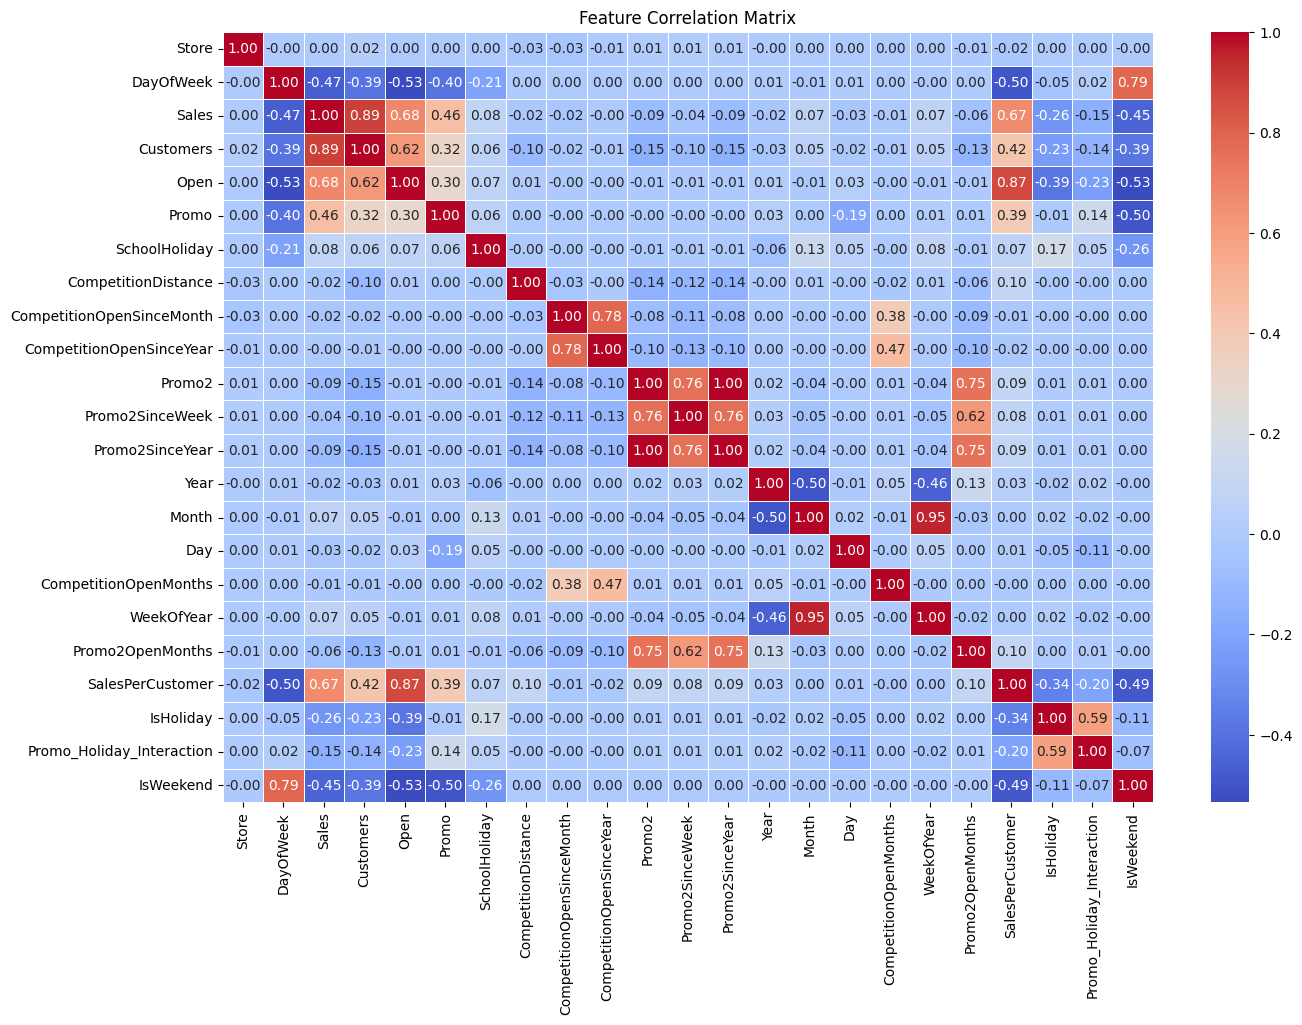

Correlation of features with Sales:
Sales                        1.000000
Customers                    0.893225
Open                         0.681948
SalesPerCustomer             0.666368
Promo                        0.457289
SchoolHoliday                0.077587
WeekOfYear                   0.067334
Month                        0.065972
Store                        0.003993
CompetitionOpenSinceYear    -0.004848
CompetitionOpenMonths       -0.008427
CompetitionDistance         -0.016716
CompetitionOpenSinceMonth   -0.019026
Year                        -0.023450
Day                         -0.030299
Promo2SinceWeek             -0.041647
Promo2OpenMonths            -0.058560
Promo2                      -0.086217
Promo2SinceYear             -0.086231
Promo_Holiday_Interaction   -0.152391
IsHoliday                   -0.263038
IsWeekend                   -0.450150
DayOfWeek                   -0.469511
Name: Sales, dtype: float64


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlation matrix for numerical columns
corr_matrix = df.select_dtypes(include=['number']).corr()

# Plotting the heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

# Display top correlations with Sales
print("Correlation of features with Sales:")
print(corr_matrix['Sales'].sort_values(ascending=False))

### Feature Encoding using Scikit-Learn

We will now use `OneHotEncoder` from `sklearn.preprocessing` and `ColumnTransformer` to handle our categorical variables. This approach is more robust for production pipelines.

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# 1. Define columns
features_to_drop = ['Sales', 'Customers', 'SalesPerCustomer', 'Date']
cat_cols = ['StoreType', 'Assortment', 'StateHoliday', 'PromoInterval', 'Quarter']

# Prepare X and y
df_model = df.copy()

# Fix: Ensure all categorical columns are strings to avoid mixed-type errors
for col in cat_cols:
    df_model[col] = df_model[col].astype(str)

X_raw = df_model.drop(columns=features_to_drop)
y = df_model['Sales']

# Identify numerical columns (all except categorical)
num_cols = [col for col in X_raw.columns if col not in cat_cols]

# 2. Setup ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ],
    remainder='passthrough' # Keep numerical columns as they are
)

# 3. Fit and Transform
X_encoded = preprocessor.fit_transform(X_raw)

# Get feature names for the new columns
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)
final_columns = list(cat_feature_names) + num_cols

X = pd.DataFrame(X_encoded, columns=final_columns, index=X_raw.index)

print(f"Encoded shape: {X.shape}")
display(X.head())

Encoded shape: (644580, 39)


,StoreType_a,StoreType_b,StoreType_c,StoreType_d,Assortment_a,Assortment_b,Assortment_c,StateHoliday_0,StateHoliday_a,StateHoliday_b,...,Promo2SinceYear,Year,Month,Day,CompetitionOpenMonths,WeekOfYear,Promo2OpenMonths,IsHoliday,Promo_Holiday_Interaction,IsWeekend
0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,2015.0,7.0,31.0,82.0,31.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,2010.0,2015.0,7.0,31.0,92.0,31.0,64.1,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,2011.0,2015.0,7.0,31.0,103.0,31.0,51.9,0.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,2015.0,7.0,31.0,70.0,31.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,2015.0,7.0,31.0,3.0,31.0,0.0,0.0,0.0,0.0


### Time-Based Split

Since this is time-series data, we shouldn't use a random split. We will use the most recent data as our validation set to simulate a real forecasting scenario.

In [27]:
# Sort by date just in case
df = df.sort_values('Date')

# Use approximately last 6 weeks for testing
# Based on the date range in the data
train_size = int(len(df_model) * 0.9)

X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (580122, 39)
Testing set size: (64458, 39)


In [28]:
# Display the full list of 35 features selected for the model
print(f"Total Features: {len(X.columns)}\n")
for i, col in enumerate(X.columns, 1):
    print(f"{i}. {col}")

Total Features: 39

1. StoreType_a
2. StoreType_b
3. StoreType_c
4. StoreType_d
5. Assortment_a
6. Assortment_b
7. Assortment_c
8. StateHoliday_0
9. StateHoliday_a
10. StateHoliday_b
11. StateHoliday_c
12. PromoInterval_Feb,May,Aug,Nov
13. PromoInterval_Jan,Apr,Jul,Oct
14. PromoInterval_Mar,Jun,Sept,Dec
15. PromoInterval_No Promo
16. Quarter_Q1
17. Quarter_Q2
18. Quarter_Q3
19. Quarter_Q4
20. Store
21. DayOfWeek
22. Open
23. Promo
24. SchoolHoliday
25. CompetitionDistance
26. CompetitionOpenSinceMonth
27. CompetitionOpenSinceYear
28. Promo2
29. Promo2SinceWeek
30. Promo2SinceYear
31. Year
32. Month
33. Day
34. CompetitionOpenMonths
35. WeekOfYear
36. Promo2OpenMonths
37. IsHoliday
38. Promo_Holiday_Interaction
39. IsWeekend


### Advanced Feature Selection: Feature Importance using Random Forest

We will use a simple Random Forest model on a sample of the data to see which features contribute most to predicting sales. This is an **Embedded Method** for feature selection.

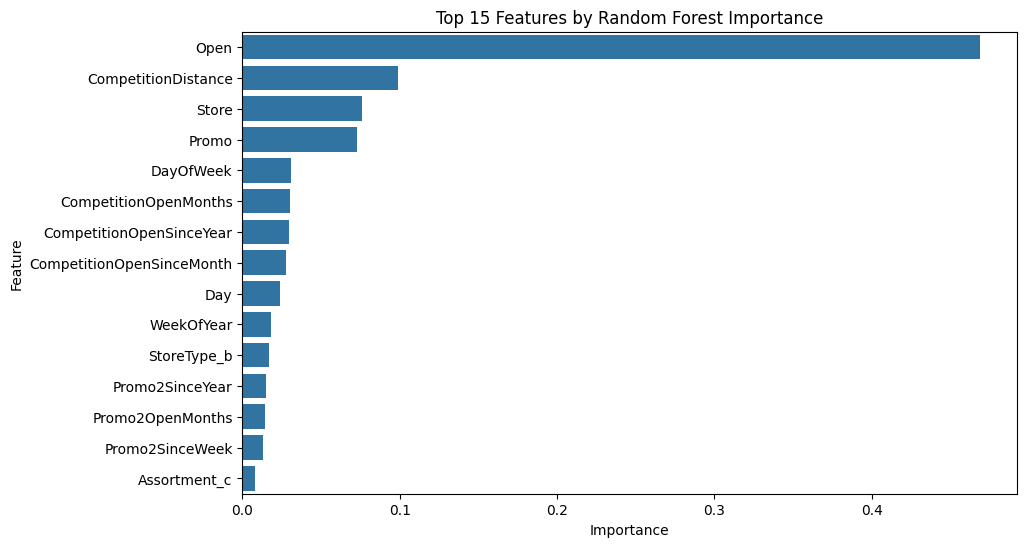

,Feature,Importance
21,Open,0.469141
24,CompetitionDistance,0.098928
19,Store,0.076030
22,Promo,0.073110
20,DayOfWeek,0.030991
33,CompetitionOpenMonths,0.030323
26,CompetitionOpenSinceYear,0.029648
25,CompetitionOpenSinceMonth,0.027890
32,Day,0.023881
34,WeekOfYear,0.018366


In [29]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

# Using a smaller sample to speed up the process
X_sample = X_train.sample(50000, random_state=42)
y_sample = y_train.loc[X_sample.index]

# Initialize and fit model
rf = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf.fit(X_sample, y_sample)

# Get feature importances
importances = rf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Plot top 15 features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15))
plt.title('Top 15 Features by Random Forest Importance')
plt.show()

display(feature_importance_df.head(10))

### Analyzing the Target Variable: 'Sales' Distribution

Total entries: 644580
Entries with zero sales: 111268
Percentage of zero sales: 17.26%


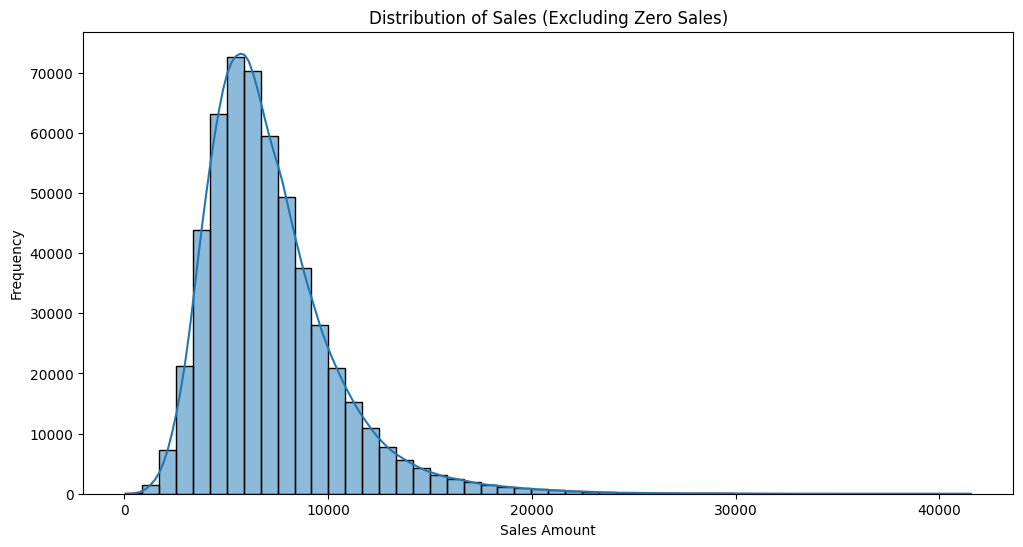


Descriptive Statistics for Sales:


,Sales
count,644580.000000
mean,5898.396306
std,3949.982929
min,0.000000
25%,3794.000000
50%,5871.000000
75%,8038.000000
max,41551.000000



Skewness of Sales: 0.63


In [31]:


i# Check for zero sales, as this can often indicate an 'imbalance' in sales data
zero_sales_count = df[df['Sales'] == 0].shape[0]
total_sales_count = df.shape[0]

print(f"Total entries: {total_sales_count}")
print(f"Entries with zero sales: {zero_sales_count}")
print(f"Percentage of zero sales: {round((zero_sales_count / total_sales_count) * 100, 2)}%")

# Visualize the distribution of Sales (excluding zero sales for better visualization of positive sales)
plt.figure(figsize=(12, 6))
sns.histplot(df[df['Sales'] > 0]['Sales'], bins=50, kde=True)
plt.title('Distribution of Sales (Excluding Zero Sales)')
plt.xlabel('Sales Amount')
plt.ylabel('Frequency')
plt.show()

# Also look at descriptive statistics for Sales
print("\nDescriptive Statistics for Sales:")
display(df['Sales'].describe())

# Check skewness
print(f"\nSkewness of Sales: {df['Sales'].skew():.2f}")

### Key Findings and Conclusion from Data Preparation

This notebook has focused on meticulously preparing the raw sales and store data for robust machine learning model development. Our key achievements and findings are:

1.  **Comprehensive Data Integration:** We successfully merged the `train` and `store` datasets, creating a unified DataFrame essential for holistic analysis.
2.  **Thorough Data Cleaning & Imputation:** Addressed missing values systematically, especially for `CompetitionDistance` and `Promo2` related fields, ensuring data completeness without losing valuable information.
3.  **Effective Feature Engineering:**
    *   **Time-Based Features:** Extracted detailed temporal features (Year, Month, Day, WeekOfYear) from the `Date` column, alongside `IsWeekend` to capture weekly patterns.
    *   **Business Logic Features:** Created `CompetitionOpenMonths` and `Promo2OpenMonths` to quantify the duration of competitive and promotional activities, offering direct business insights.
    *   **Derived Metrics:** Introduced `SalesPerCustomer` to understand customer spending behavior and `Promo_Holiday_Interaction` to analyze combined effects.
    *   **Categorical Grouping:** Divided `Month` into `Quarter` to identify seasonal trends.
4.  **Target Variable Analysis:** Identified a significant proportion of zero sales entries (17.26%), leading to the strategic decision of a two-part modeling approach (classification for sales occurrence, regression for sales amount).
5.  **Feature Selection & Encoding:** Used correlation analysis and Random Forest feature importance to identify key predictors. Categorical features were robustly encoded using `OneHotEncoder`, preparing them for diverse ML algorithms.
6.  **Time-Series Data Splitting:** Implemented a time-based train-test split to maintain temporal integrity, crucial for accurate forecasting and preventing data leakage.

**Overall Conclusion:** We have transformed disparate raw data into a clean, feature-rich, and well-structured dataset. This processed DataFrame is now primed for advanced machine learning model training, effectively addressing data quality issues and creating meaningful predictors to build powerful sales forecasting solutions.

### Saving Prepared Data to Google Drive

To facilitate model building in a new notebook without re-running the entire data preparation pipeline, we will save the final processed DataFrame (`df`) to Google Drive.

In [41]:
from google.colab import drive
import os

drive.mount('/content/drive')

# Define a path in your Google Drive
drive_path = '/content/drive/MyDrive/processed_rossmann_sales_data.csv'

# Save the DataFrame to CSV in Google Drive
df.to_csv(drive_path, index=False)

print(f"Processed DataFrame saved to: {drive_path}")

# To load this data in a new notebook:
# from google.colab import drive
# import pandas as pd
# drive.mount('/content/drive')
# loaded_df = pd.read_csv('/content/drive/MyDrive/processed_rossmann_sales_data.csv')
# print(loaded_df.head())

Mounted at /content/drive
Processed DataFrame saved to: /content/drive/MyDrive/processed_rossmann_sales_data.csv
